## Import Libraries and Set DataFrame 

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset from sklearn
from sklearn.datasets import load_iris

print ("==" *50)
print("Successfully imported libraries and loaded the dataset!")
print ("==" *50)

Successfully imported libraries and loaded the dataset!


## Create DataFrame

In [2]:
# Lets load the dataset and create a DataFrame
iris = load_iris()
# Create a DataFrame from the iris dataset
df = pd.DataFrame(iris.data, columns=iris.feature_names)
# Add the target variable to the DataFrame
df['species'] = iris.target

print ("==" *50)
print(df.head())

print ("==" *50)
print(df.shape)

print ("==" *50)
print(df.info())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64 

In [3]:
# EDA: Exploratory Data Analysis
print("==" *50)
print("Missing Values:")
print(df.isnull().sum())

print("==" *50)
print("Basic Statistics:")
print(df.describe())

print("==" *50)
print("Species Count:")
print(df['species'].value_counts())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64
Basic Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000 

## Use Seaborn for Visualization

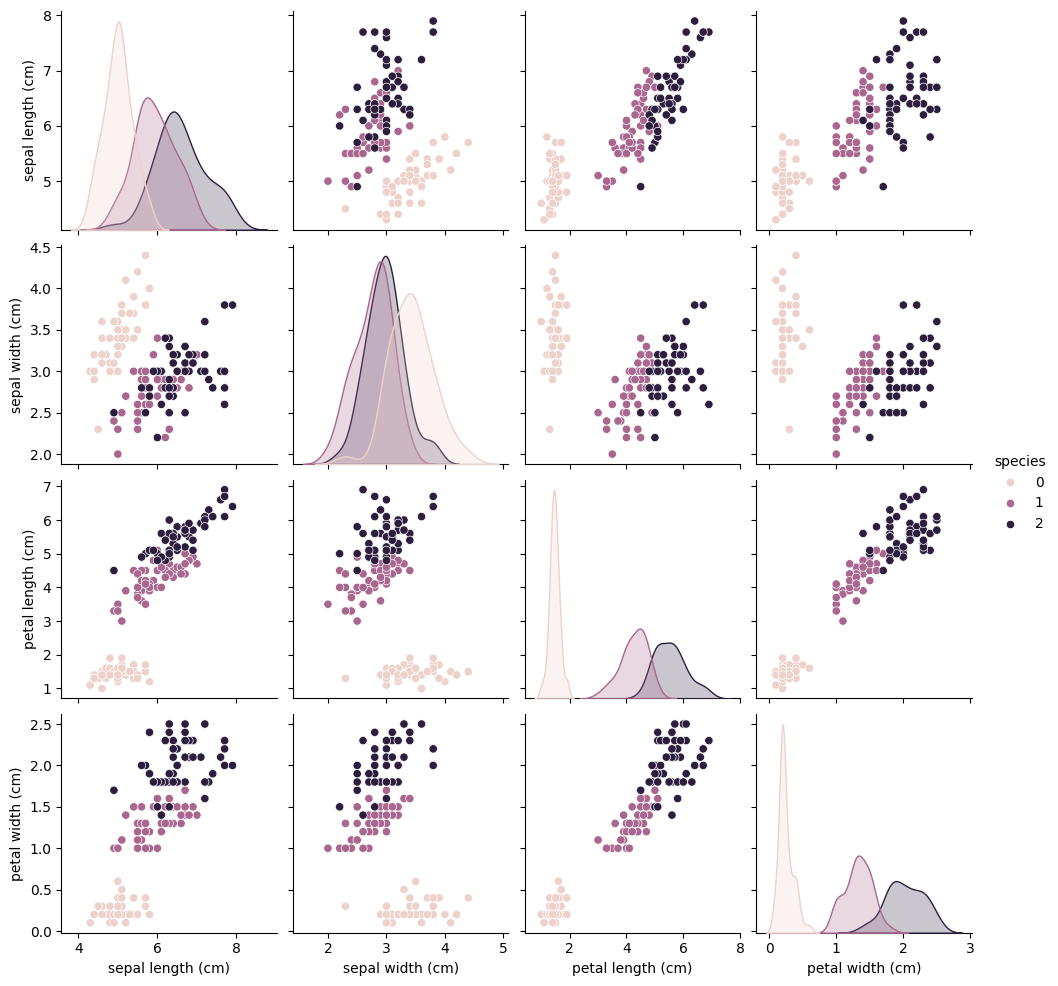

In [4]:
# Visualization
# Pairplot - shows relationship between each feature
# hue=species assigns different color to each species
sns.pairplot(df, hue='species')
plt.show()

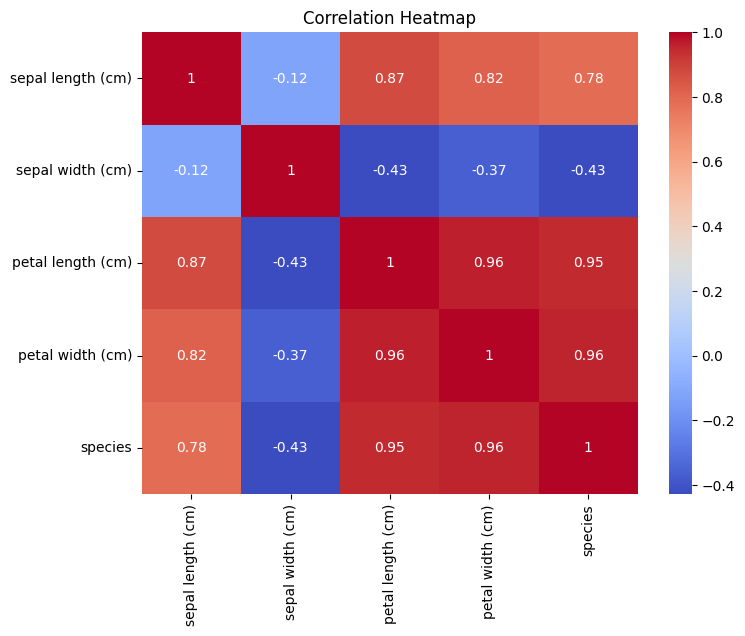

In [5]:
# 2. Correlation Heatmap to visualize correlations between features
# Heatmap - shows correlation between features (-1 to 1)
# annot=True displays numbers on heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

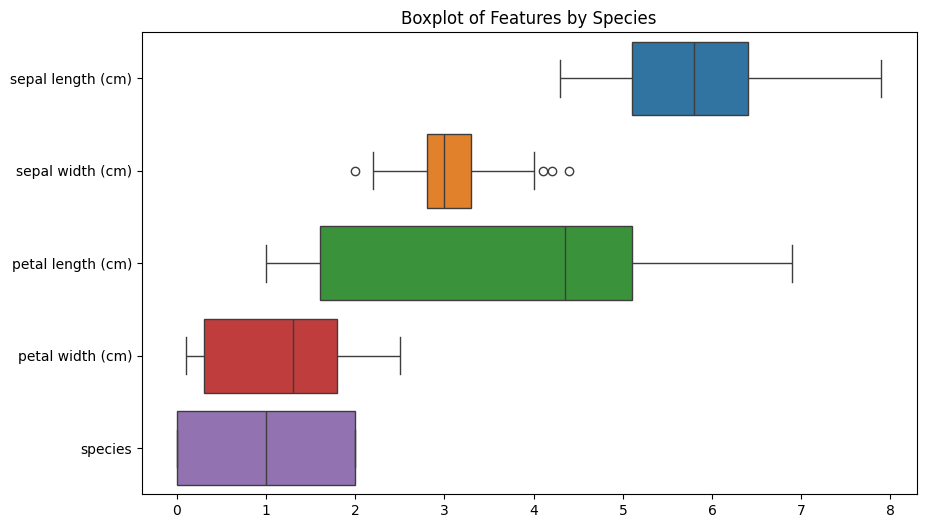

In [6]:
# 3. Boxplot to visualize feature distributions by species
# Boxplot - shows min, max, median and outliers of each feature
plt.figure(figsize=(10,6))
sns.boxplot(data=df, orient='h') # orient='h' renders horizontal boxplot
plt.title('Boxplot of Features by Species')
plt.show()

# Decision Tree 

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.metrics import accuracy_score, classification_report

# Separate features and target variable
# X contains all features except 'species'
# y contains the 'species' column
X = df.drop('species', axis=1)
y = df['species']

print ('==' *30)
print('Successfully separated features and target variable!')
print ('==' *30)

Successfully separated features and target variable!


In [12]:
# Split into traning and testing sets (80% train, 20% test)
# test_size=0.2 means 20% of data will be used for testing
# random_state=42 ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print ('==' *30)
print('Successfully split data into training and testing sets!')
print ('==' *30)

Successfully split data into training and testing sets!


In [13]:
# Train Decision Tree Classifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
print ('==' *30)
print('Successfully trained the Decision Tree Classifier!')
print ('==' *30)

Successfully trained the Decision Tree Classifier!


In [14]:
# Predict and evaluate the model
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



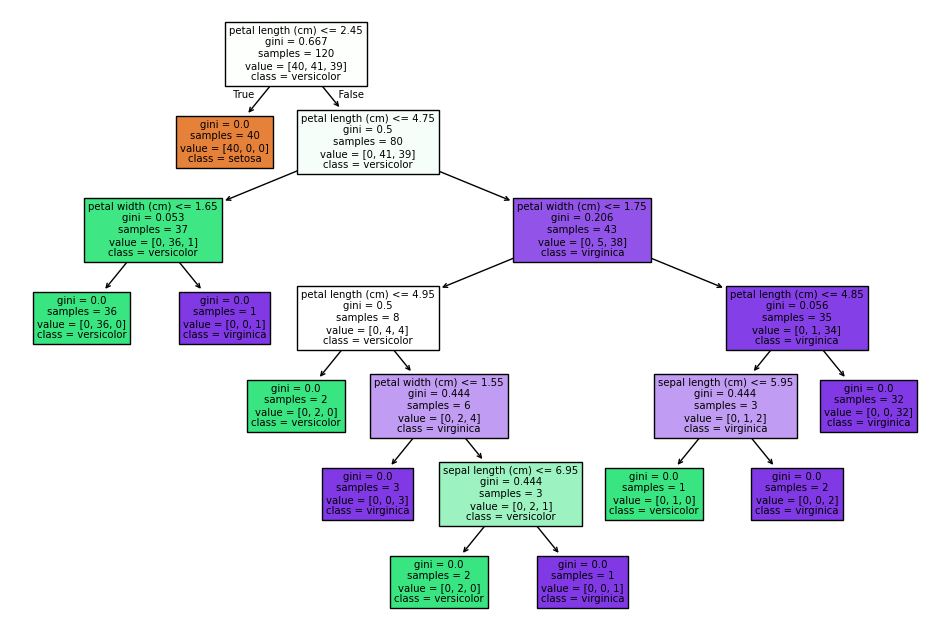

In [15]:
# Visualize the Decision Tree
plt.figure(figsize=(12,8))
# plot_tree visualizes the structure of the decision tree, feature_names and class_names provide labels, filled=True colors the nodes
plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()